In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import regex as re
import nltk
from nltk.tokenize import sent_tokenize , word_tokenize
from collections import Counter
import spacy
import networkx as nx
from gensim import corpora , models
import joblib

In [2]:
files = [
    "data/001ssb.txt",
    "data/002ssb.txt",
    "data/003ssb.txt",
    "data/004ssb.txt",
    "data/005ssb.txt",
]

text = ""

for file in files:
    with open(file, "r", encoding="latin-1") as f:
        text += f.read() + "\n"

In [3]:
len(text)

9778338

In [4]:
text[:1000]

'A Game Of Thrones \nBook One of A Song of Ice and Fire \nBy George R. R. Martin \nPROLOGUE \n"We should start back," Gared urged as the woods began to grow dark around them. "The wildlings are \ndead." \n"Do the dead frighten you?" Ser Waymar Royce asked with just the hint of a smile. \nGared did not rise to the bait. He was an old man, past fifty, and he had seen the lordlings come and go. \n"Dead is dead," he said. "We have no business with the dead." \n"Are they dead?" Royce asked softly. "What proof have we?" \n"Will saw them," Gared said. "If he says they are dead, that\'s proof enough for me." \nWill had known they would drag him into the quarrel sooner or later. He wished it had been later rather \nthan sooner. "My mother told me that dead men sing no songs," he put in. \n"My wet nurse said the same thing, Will," Royce replied. "Never believe anything you hear at a woman\'s \ntit. There are things to be learned even from the dead." His voice echoed, too loud in the twilit fores

# **Text Preprocessing**

In [5]:
import string
exclude = string.punctuation

In [6]:
def preprocess(text):

    text = text.lower()
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

def remove_punchuations(text):
    clean_text = []
    for char in text.split():
        if char not in exclude:
            clean_text.append(char)
    
    return " ".join(clean_text)

clean_text = preprocess(text)
clean_text = remove_punchuations(clean_text)

# **Sentence Tokenizer**

In [7]:
# sentence = sent_tokenize(text)
# sentence[:10]

In [8]:
# text = re.sub(r'[^a-zA-Z\s]' , '' , text)

# **Word Tokenizer**

In [9]:
tokens = word_tokenize(clean_text)

In [10]:
tokens[:30]

['a',
 'game',
 'of',
 'thrones',
 'book',
 'one',
 'of',
 'a',
 'song',
 'of',
 'ice',
 'and',
 'fire',
 'by',
 'george',
 'r',
 'r',
 'martin',
 'prologue',
 'we',
 'should',
 'start',
 'back',
 'gared',
 'urged',
 'as',
 'the',
 'woods',
 'began',
 'to']

In [11]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

tokens = [w for w in tokens if w not in stop_words]

In [12]:
custom_stopwords = {
    "said","would","one","could","back","well","like",
    "man","men","lord","ser","know","jon","told","even",
    "made","see","never","time","way","might","still"
}

tokens = [w for w in tokens if w not in custom_stopwords]

In [13]:
joblib.dump(tokens, "models/tokens.joblib")

['models/tokens.joblib']

# **Token Frequency**

In [14]:
freq = Counter(tokens)

print(freq.most_common(50))

[('old', 2754), ('hand', 2703), ('king', 2694), ('tyrion', 2567), ('eyes', 2519), ('thought', 2434), ('black', 2388), ('lady', 2351), ('long', 2253), ('us', 2251), ('come', 2238), ('father', 2162), ('face', 2106), ('head', 2071), ('page', 2020), ('must', 1992), ('good', 1923), ('boy', 1920), ('red', 1910), ('little', 1897), ('two', 1874), ('took', 1874), ('came', 1857), ('though', 1813), ('say', 1802), ('away', 1761), ('dead', 1739), ('brother', 1723), ('take', 1691), ('go', 1686), ('blood', 1665), ('make', 1653), ('son', 1649), ('queen', 1644), ('saw', 1609), ('kings', 1599), ('three', 1593), ('arya', 1585), ('first', 1546), ('day', 1531), ('look', 1521), ('want', 1519), ('night', 1515), ('much', 1503), ('enough', 1502), ('tell', 1475), ('white', 1469), ('jaime', 1466), ('sword', 1457), ('looked', 1453)]


In [15]:
joblib.dump(freq, "models/word_freq.joblib")

['models/word_freq.joblib']

# **Named Entity Recognization**

In [16]:
len(text)

9778338

In [17]:
nlp = spacy.load("en_core_web_sm") 

doc = nlp(clean_text[:100000])

character = []

for ent in doc.ents:
    if ent.label_ == "PERSON":
        character.append(ent.text)

print(set(character))

{'robert baratheon', 'benjen stark', 'knelt', 'robert grasped', 'robert nodded', 'khal drogos', 'drogo', 'muster jon', 'khal moro', 'bush', 'harwin', 'robert arryn', 'nan', 'catelyn catelyn', 'joffrey baratheon', 'robert muttered', 'robert swore', 'gaunt', 'prince joffrey', 'catelyn reminded', 'robert followed', 'waymar', 'shaggy grey', 'catelyn', 'ben stark', 'robert complained', 'jorah', 'robert of', 'bran catelyn', 'menagerie', 'robert embraced catelyn', 'jon arryn', 'stark jon', 'robert', 'maester aemon', 'dothraki', 'danys head', 'lyanna', 'george r r martin prologue', 'maester luwin', 'stark', 'robert have', 'catelyn knew', 'jaime', 'neds king', 'jon robert', 'jory desmond', 'robert looked', 'robert himself', 'ben', 'wolf', 'jon snow'}


In [18]:
joblib.dump(nlp, "models/spacy_model.joblib")

['models/spacy_model.joblib']

# **Character Graph**

In [19]:
import itertools

def build_character_network(text, nlp):

    doc = nlp(text)

    G = nx.Graph()

    for sent in doc.sents:

        characters = [
            ent.text
            for ent in sent.ents
            if ent.label_ == "PERSON"
        ]

        for pair in itertools.combinations(set(characters), 2):

            if G.has_edge(*pair):
                G[pair[0]][pair[1]]["weight"] += 1
            else:
                G.add_edge(pair[0], pair[1], weight=1)

    return G

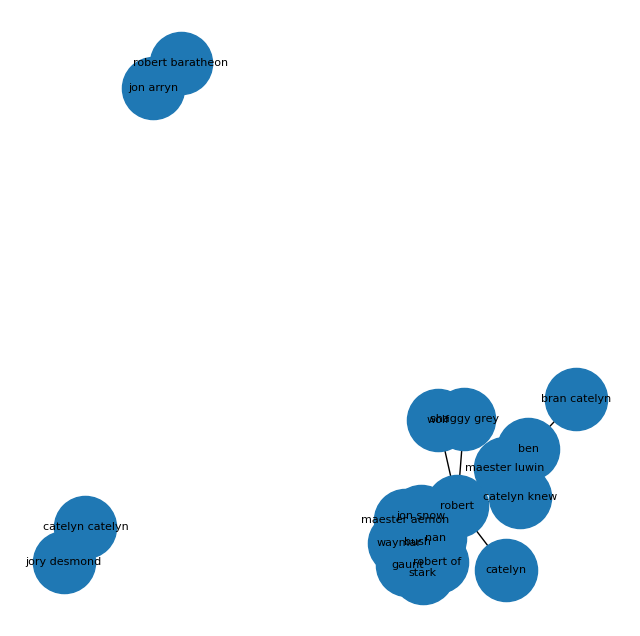

In [20]:
G = build_character_network(clean_text[:50000], nlp)

fig, ax = plt.subplots(figsize=(8,8))

nx.draw(
    G,
    with_labels=True,
    node_size=2000,
    font_size=8
)

In [21]:
joblib.dump(G, "models/character_graph.joblib")

['models/character_graph.joblib']

# **LDA (Latent Dirichlet Allocation)**

In [22]:
from gensim import corpora, models
from gensim.models import Phrases, TfidfModel
from gensim.models.phrases import Phraser

# --------------------------------
# SPLIT INTO DOCUMENTS
# --------------------------------

documents = [tokens[i:i+800] for i in range(0, len(tokens), 800)]

# --------------------------------
# CREATE BIGRAMS
# --------------------------------

phrases = Phrases(documents, min_count=5, threshold=10)
bigram = Phraser(phrases)

documents = [bigram[doc] for doc in documents]

# --------------------------------
# DICTIONARY
# --------------------------------

dictionary = corpora.Dictionary(documents)

dictionary.filter_extremes(
    no_below=5,
    no_above=0.4
)

# --------------------------------
# CORPUS
# --------------------------------

corpus = [dictionary.doc2bow(doc) for doc in documents]

# --------------------------------
# TF-IDF MODEL
# --------------------------------

tfidf = TfidfModel(corpus)

corpus_tfidf = tfidf[corpus]

# --------------------------------
# LDA MODEL
# --------------------------------

lda = models.LdaModel(
    corpus=corpus_tfidf,
    id2word=dictionary,
    num_topics=5,
    passes=30,
    random_state=42
)

# --------------------------------
# PRINT HUMAN READABLE TOPICS
# --------------------------------

topics = lda.show_topics(num_topics=5, num_words=10, formatted=False)

for topic_id, words in topics:
    
    word_list = [word for word, prob in words]

    print(f"\nTopic {topic_id+1}")
    print(", ".join(word_list))


Topic 1
ned, arya, catelyn, lommy, robb, yoren, hot_pie, sansa, brienne, bran

Topic 2
united, w, box, palace, street, kingdom, east, road, new, sansa

Topic 3
gared, asha, tyrion, davos, victarion, dany, bran, snow, sam, euron

Topic 4
tyrion, bran, arya, jaime, weese, cersei, brienne, pate, kevan, dany

Topic 5
tyrion, dany, arya, bran, jaime, sam, sansa, ned, davos, catelyn


In [23]:
joblib.dump(lda, "models/lda_model.joblib")
joblib.dump(dictionary, "models/lda_dictionary.joblib")

['models/lda_dictionary.joblib']

In [24]:
from transformers import GPT2Tokenizer , GPT2LMHeadModel

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

C:\Users\LeoML\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\LeoML\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [25]:
# from transformers import AutoTokenizer, AutoModelForCausalLM

# tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
# model = AutoModelForCausalLM.from_pretrained("distilgpt2")

In [26]:
prompt = "The night was cold and the wall stood silent"

inputs = tokenizer.encode(prompt, return_tensors="pt")

output = model.generate(
    inputs,
    max_length=100,
    num_return_sequences=1,
    temperature=0.8,
    do_sample=True
)

generated_text = tokenizer.decode(output[0], skip_special_tokens=True)

print(generated_text)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


The night was cold and the wall stood silent. Then a heavy wind hit the rock. The black sun shot through the darkness and the black wind broke the rock and the black rock broke again and again. The walls were cracked, there was smoke from their holes and the smoke was like the shadow of an angry lion. A young woman came up from the shadows and came up with a sword. A young man came up from the shadows and came up with a sword. The young man came up with


In [27]:
model.save_pretrained("models/gpt2")
tokenizer.save_pretrained("models/gpt2")

('models/gpt2\\tokenizer_config.json',
 'models/gpt2\\special_tokens_map.json',
 'models/gpt2\\vocab.json',
 'models/gpt2\\merges.txt',
 'models/gpt2\\added_tokens.json')